In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv("data\zomato.csv")
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [4]:
df.columns = df.columns.str.strip()

In [5]:
df.isnull().sum()

df = df.dropna(subset=['rate', 'votes', 'location'])

In [6]:
df['rate'] = df['rate'].str.replace('/5', '')
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [7]:
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

In [8]:
total_orders = df['votes'].sum()
print("Total Orders (proxy):", total_orders)

Total Orders (proxy): 14651623


In [9]:
print("Average Rating:", df['rate'].mean())
print("Average Votes:", df['votes'].mean())

Average Rating: 3.700448817952718
Average Votes: 333.43095443994355


In [10]:
online_orders = df['online_order'].value_counts()
online_orders

online_order
Yes    28308
No     15634
Name: count, dtype: int64

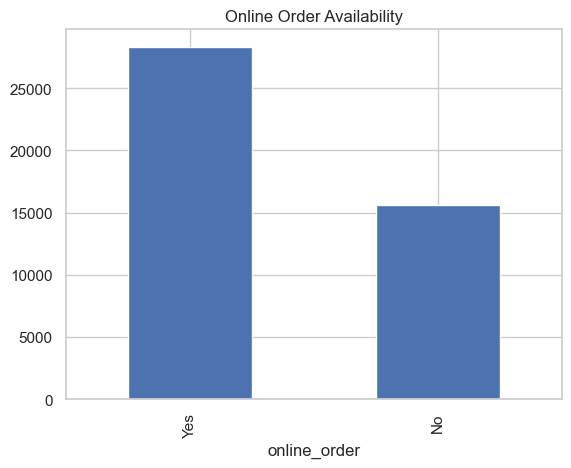

In [11]:
online_orders.plot(kind='bar')
plt.title("Online Order Availability")
plt.show()

In [12]:
location_demand = df.groupby('location')['votes'].sum().sort_values(ascending=False)
location_demand.head(10)

location
Koramangala 5th Block    2219506
Indiranagar              1196007
Koramangala 4th Block     685156
BTM                       617880
Church Street             594979
JP Nagar                  578071
Lavelle Road              506186
HSR                       499720
Koramangala 7th Block     495324
Jayanagar                 481285
Name: votes, dtype: int64

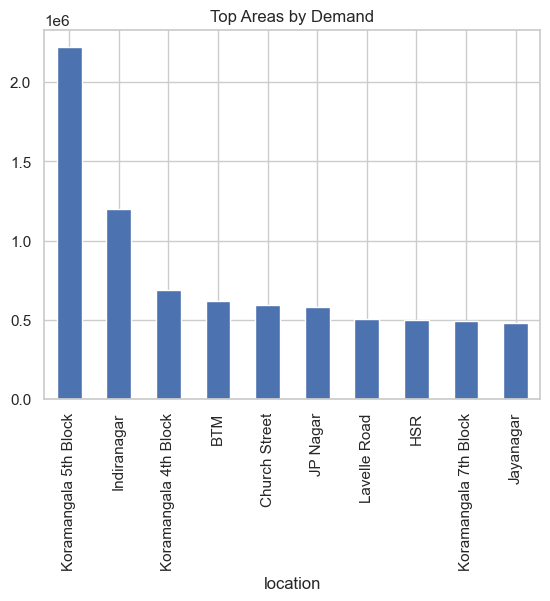

In [13]:
location_demand.head(10).plot(kind='bar')
plt.title("Top Areas by Demand")
plt.show()

In [15]:
top_restaurants = df.sort_values(by='votes', ascending=False)

top_restaurants[['name', 'location', 'votes']].head(10)

,name,location,votes
50059,Byg Brewski Brewing Company,Sarjapur Road,16832
49627,Byg Brewski Brewing Company,Sarjapur Road,16832
49170,Byg Brewski Brewing Company,Sarjapur Road,16832
4801,Byg Brewski Brewing Company,Sarjapur Road,16345
3921,Byg Brewski Brewing Company,Sarjapur Road,16345
4944,Byg Brewski Brewing Company,Sarjapur Road,16345
19268,Toit,Indiranagar,14956
18643,Toit,Indiranagar,14956
36668,Truffles,Koramangala 5th Block,14726
33913,Truffles,Koramangala 5th Block,14723


In [16]:
top_rated = df.sort_values(by='rate', ascending=False)

top_rated[['name', 'rate', 'location']].head(10)

,name,rate,location
50059,Byg Brewski Brewing Company,4.9,Sarjapur Road
32110,Asia Kitchen By Mainland China,4.9,Koramangala 5th Block
43055,Belgian Waffle Factory,4.9,Brigade Road
8260,AB's - Absolute Barbecues,4.9,BTM
42381,Belgian Waffle Factory,4.9,Brigade Road
3921,Byg Brewski Brewing Company,4.9,Sarjapur Road
17877,Belgian Waffle Factory,4.9,Brigade Road
4944,Byg Brewski Brewing Company,4.9,Sarjapur Road
31069,Asia Kitchen By Mainland China,4.9,Koramangala 5th Block
10389,AB's - Absolute Barbecues,4.9,BTM


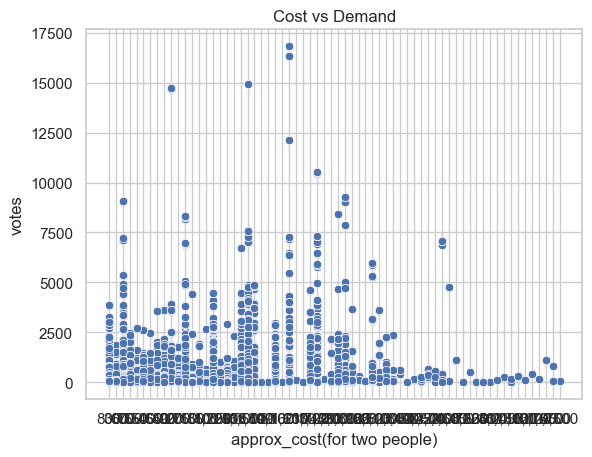

In [17]:
sns.scatterplot(x='approx_cost(for two people)', y='votes', data=df)
plt.title("Cost vs Demand")
plt.show()

In [18]:
problem = df[(df['rate'] < 3.5) & (df['votes'] > df['votes'].mean())]

problem[['name', 'rate', 'votes', 'location']].head()

,name,rate,votes,location
31,Foodiction,2.8,506,Banashankari
195,Olive - Era,3.3,511,Kumaraswamy Layout
657,Foodiction,2.8,506,Banashankari
779,Soho Bar & Grill,2.7,377,Basavanagudi
862,Soho Bar & Grill,2.7,377,Basavanagudi


In [19]:
total_orders
online_orders
location_demand.head()
top_restaurants.head()
top_rated.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
50059,https://www.zomato.com/bangalore/byg-brewski-b...,"Behind MK Retail, Sarjapur Road, Bangalore",Byg Brewski Brewing Company,Yes,Yes,4.9,16832,+91 8039514766,Sarjapur Road,Microbrewery,"Cocktails, Butter Chicken, Dahi Kebab, Rajma C...","Continental, North Indian, Italian, South Indi...","1,600","[('Rated 4.0', 'RATED\n Visiting a microbrewe...",[],Drinks & nightlife,Sarjapur Road
32110,https://www.zomato.com/bangalore/asia-kitchen-...,"136, Ground Floor, 1st Cross, 5th Block, Jyoti...",Asia Kitchen By Mainland China,Yes,Yes,4.9,2244,080 49652573,Koramangala 5th Block,"Casual Dining, Bar","Noodles, Chicken Dim Sum, Pad Thai Noodle, Jum...","Asian, Chinese, Thai, Momos","1,500","[('Rated 3.0', 'RATED\n Hmm not great not bad...",[],Buffet,Koramangala 6th Block
43055,https://www.zomato.com/bangalore/belgian-waffl...,"65, Markham Road, Ashok Nagar, Brigade Road, B...",Belgian Waffle Factory,Yes,No,4.9,1750,+91 9481511911,Brigade Road,Dessert Parlor,"Coffee, Berryblast, Nachos, Chocolate Waffles,...",Desserts,400,"[('Rated 4.0', ""RATED\n Looks like there's a ...","['The Red Wonder Waffle [Bubble]', 'Bubble Kit...",Desserts,MG Road
8260,https://www.zomato.com/bangalore/abs-absolute-...,"100 Feet Road, 1st Phase, Near Jayadeva Flyove...",AB's - Absolute Barbecues,No,Yes,4.9,6375,040 45659912,BTM,Casual Dining,"Tangdi Chicken, Bbq Buffet, Chocolate Icecream...","European, Mediterranean, North Indian, BBQ","1,600","[('Rated 5.0', 'RATED\n We liked the place a ...",[],Buffet,BTM
42381,https://www.zomato.com/bangalore/belgian-waffl...,"65, Markham Road, Ashok Nagar, Brigade Road, B...",Belgian Waffle Factory,Yes,No,4.9,1750,+91 9481511911,Brigade Road,Dessert Parlor,"Coffee, Berryblast, Nachos, Chocolate Waffles,...",Desserts,400,"[('Rated 4.0', ""RATED\n Looks like there's a ...","['The Red Wonder Waffle [Bubble]', 'Bubble Kit...",Delivery,MG Road
